# Operationalizing Soundmarks: A Data-Driven Validation of Typicality, Salience, and Uniqueness in European Cities

This script implements all experiments, which are documented in the article.

**Author**: Jakob Abeßer (jakob.abesser@uni-bamberg.de)

**Last Change**: 09.03.2026


In [18]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os 
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.patches import Circle

from scipy.stats import entropy, pearsonr, kruskal
import scikit_posthocs as sp

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, LeavePGroupsOut, GroupKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge



# change font size to match Elsevier article style (times)
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,   # TrueType
    "ps.fonttype": 42,
})

In [19]:
def load_sound_class_labels_for_pann():
    """ Load sound class labels for PANN SED model
    Args:
        -
    Returns:
        sound_class_labels (list of str): Sound class labels (n_classes)
    """
    # Read the CSV file into a DataFrame
    df = pd.read_csv('data/class_labels_indices.csv')

    # Extract the "display_name" column as a list of strings
    sound_class_labels = df['display_name'].tolist()

    return sound_class_labels


## Parameters

In [20]:
# Minimum number of events per (city, scene, sound class) triple to be considered
MIN_NUM_EVENTS = 1

# Colors for 4 sound categories 'anthropophonic', 'biophonic', 'geophonic', 'miscellaneous'
SOUND_CAT_COLORS = [[1, 0, 0], [0, 1, 0], [1, 1, 0], [0.5, 0.5, 0.5]]

# sound category labels
SOUND_CAT_LABELS = ['anthropophonic', 'biophonic', 'geophonic', 'miscellaneous']

## Data import

In [21]:
# import CSV file with LLM prediction and STU metrics
fn_csv = 'data/soundmark_scores_with_metrics.csv'
df = pd.read_csv(fn_csv)
print(df.shape)
print(df.columns)

# prevent nans
df["soundmark_score"].fillna(0.0, inplace=True)

unique_cities = sorted(list(set(df['city'])))
n_cities = len(unique_cities)

unique_scenes = sorted(list(set(df['scene'])))
n_scenes = len(unique_scenes)

city_ids = pd.Categorical(df['city'], categories=unique_cities).codes


(52700, 9)
Index(['city', 'scene', 'sound_class', 'soundmark_score', 'explanation', 'S',
       'T', 'U', 'N_events'],
      dtype='object')


In [22]:
# import PANN sound class labels
class_labels = load_sound_class_labels_for_pann()
n_sound_classes = len(class_labels)
print(class_labels[:10])
print(len(class_labels))

['Speech', 'Male speech, man speaking', 'Female speech, woman speaking', 'Child speech, kid speaking', 'Conversation', 'Narration, monologue', 'Babbling', 'Speech synthesizer', 'Shout', 'Bellow']
527


## Sound class categorization (and corresponding AudioSet classes)

- **biophonic**: sounds produced by non-human living organisms (animals, insects, birds).
  - Non-human living organisms only (animals, birds, insects, amphibians, mammals)
  - Includes both vocalizations and movement sounds (e.g., wing flaps)
- **anthropophonic**: sounds produced by humans, human bodies, human activities, machines, tools, vehicles, music, electronics (including synthetic speech/music).
  - All Speech, Music, Human sounds, Human activities
  - All Tools, machines, vehicles, alarms, electronics
  - All synthetic / electronic / musical sounds
- **geophonic**: non-biological natural sounds (wind, water, weather, fire, geological events).
  - Natural, non-biological sources (wind, rain, water, thunder, fire, etc.)
- **miscellaneous**: sound qualities, signal descriptions, acoustic effects, environments, abstractions, or labels that are not concrete sources.
  - Signal abstractions, acoustic effects, environments: e.g. noise types, reverberation, echo, silence, synthetic tones

In [23]:
# import mapping CSV between AudioSet ontology labels to soundscape labels (anthropophonic, biophonic, geophonic, miscellaneous)
dfss = pd.read_csv('data/class_labels_pann_soundscape_classes.csv', delimiter=',')

""" Content (first three rows):

index,mid,display_name,classification
0,/m/09x0r,Speech,anthropophonic
1,/m/05zppz,"Male speech, man speaking",anthropophonic

"""

assert list(dfss["display_name"]) == class_labels

# create mapping dictionaries between sound category labels and indices
unique_sound_categories = sorted(list(set(dfss["classification"])))
ss_class_mapping = {unique_sound_categories[_]: _ for _ in range(len(unique_sound_categories))}
ss_class_mapping_back = {_: unique_sound_categories[_] for _ in range(len(unique_sound_categories))}

# compute sound class ids for all sound classes (assuming same sound class label order as in class_labels)
ss_class = np.array([ss_class_mapping[_] for _ in dfss["classification"]])

# show number of sound classes per category
print('## Number of sound classes per sound category \n')
for i in range(4):
    print(f"{ss_class_mapping_back[i]}:{np.sum(ss_class==i)}")
    
print("Total number of classes: ", len(ss_class))

## Number of sound classes per sound category 

anthropophonic:387
biophonic:65
geophonic:17
miscellaneous:58
Total number of classes:  527


In [24]:
def format_correlation(r, p):
    """
    Format correlation result as:
    r=.55 (p<.01)

    Rules:
    - r rounded to two decimals
    - (p<.001) if p < .001
    - (p<.01)  if p < .01
    - (p<.05)  if p < .05
    - (n.s.)   otherwise
    """

    # Round r to two decimals
    r_rounded = round(r, 2)

    # APA-style formatting (no leading zero)
    r_str = f"{r_rounded:.2f}"
    if r_str.startswith("0"):
        r_str = r_str[1:]
    elif r_str.startswith("-0"):
        r_str = "-" + r_str[2:]

    # Determine p-value label
    if p < 0.001:
        p_str = "(p<.001)"
    elif p < 0.01:
        p_str = "(p<.01)"
    elif p < 0.05:
        p_str = "(p<.05)"
    else:
        p_str = "(n.s.)"

    return f"r={r_str} {p_str}"

In [25]:
# feature columns
columns = ["S", "T", "U", "soundmark_score"]
columns_features = columns.copy()
columns_features.remove('soundmark_score')
print(columns_features)

['S', 'T', 'U']


In [26]:
# keep only (city, scene, sound) triples which were actually found as sound events in the data
n_before = df.shape[0]
min_event_mask = df["N_events"] >= MIN_NUM_EVENTS
print(min_event_mask.shape)
n_after = np.sum(min_event_mask)
print(f"{n_after}/{n_before} (city, scene, sound) triples were actually found in the audio data with >= {MIN_NUM_EVENTS} sound events.")

(52700,)
588/52700 (city, scene, sound) triples were actually found in the audio data with >= 1 sound events.


## Feature extraction from LLM-predicted soundmark scores

In [27]:
df_min_events = df.copy()

unique_cities = list(unique_cities)
class_labels  = list(class_labels)
n_cities = len(unique_cities)
n_sound_classes = len(class_labels)

# mapping dict
sound_to_cat = {class_labels[i]: int(ss_class[i]) for i in range(n_sound_classes)}

max_soundmark_score = np.zeros((n_cities, n_sound_classes)) 
unique_sounds = sorted(class_labels)
n_sound_events_per_category = np.zeros(4)
was_observed = np.zeros((n_cities, n_sound_classes), dtype=bool)

city_labels = df_min_events["city"]
sound_class_labels = df_min_events["sound_class"]
scene_labels = df_min_events["scene"]

# iterate over cities and sounds
for c, city in enumerate(tqdm(unique_cities)):
    for s, sound_class in enumerate(class_labels): 

        # find rows in df_min_events that corresponds to current (city, sound)
        mask = np.logical_and(city_labels == city,
                              sound_class_labels == sound_class)
        
        # this should always be fulfilled, 
        if np.sum(mask) > 0:
            
            # LLM-predicted soundmark scores of all scenes for current (city, sound)
            curr_soundmark_scores = np.array(df_min_events.loc[mask, "soundmark_score"].tolist())

            # store only maximum across scenes
            max_soundmark_score[c, s] = np.max(curr_soundmark_scores)

            # store also the total number of sound events in the respective sound category (1/4 classes)
            curr_sound_category = ss_class[s]
            n_sound_events_per_category[curr_sound_category] += np.sum(np.array(df_min_events.loc[mask, "N_events"].tolist()))

        
# was_observed: any scene with N_events > 0 for each (city, sound_class)
obs_df = (
    df_min_events.assign(_pos=df_min_events["N_events"].to_numpy() > 0)
    .pivot_table(
        index="city",
        columns="sound_class",
        values="_pos",
        aggfunc="any",
        dropna=False
    )
    .reindex(index=unique_cities, columns=class_labels)
)
was_observed = obs_df.fillna(False).to_numpy(dtype=bool)

print("Total number of events per category")
for i in range(4):
    print(f"{ss_class_mapping_back[i]}: {n_sound_events_per_category[i]}")
print(f"Total: {n_sound_events_per_category.sum()} sound events")
            
# highest soundmark score for each sound class across all cities
max_soundmark_score_per_city = max_soundmark_score.max(axis=0)

# normalized entropy (bound to (0, 1)) across all cities
city_sound_uniqueness = 1 - entropy(max_soundmark_score + 1e-10, axis=0) / np.log(n_cities)

# mask if sounds were observed across cities
was_observed_across_cities = np.any(was_observed, axis=0)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:29<00:00,  2.92s/it]

Total number of events per category
anthropophonic: 1095.0
biophonic: 145.0
geophonic: 110.0
miscellaneous: 244.0
Total: 1594.0 sound events


## Histogram over both features

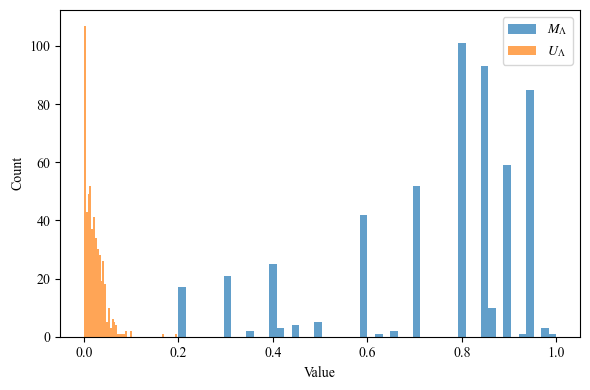

In [28]:
plt.figure(figsize=(6, 4))
plt.hist(max_soundmark_score_per_city, bins=50, alpha=0.7, label=r'$M_\mathrm{\Lambda}$')
plt.hist(city_sound_uniqueness, bins=50, alpha=0.7, label=r'$U_\mathrm{\Lambda}$')
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## Scatterplot over both features for 4 sound categories

anthropophonic
29
r=-.04 (n.s.)

biophonic
16
r=-.07 (n.s.)

geophonic
10
r=-.27 (n.s.)

miscellaneous
6
r=-.32 (p<.05)



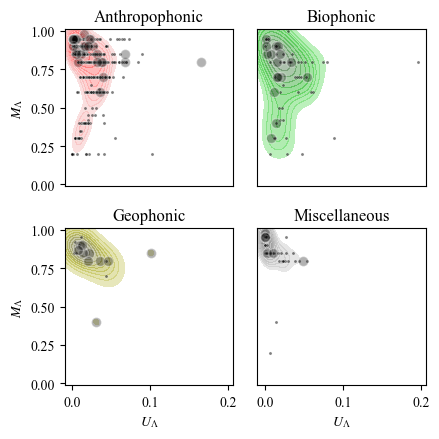

In [29]:
# create feature matrix from two features: 
#  (1) uniqueness
#  (2) max score across scenes
X = np.vstack((city_sound_uniqueness, max_soundmark_score_per_city)).T  # (n_sounds, 2)
y = ss_class # (n_sounds,)

# get max feature values to set axis range later
max_score = max_soundmark_score_per_city.max()
max_uniqueness = city_sound_uniqueness.max()

# setup the figure
plt.figure(figsize=(4.5,4.5))
      
# Iterate over soundscape categories
# {'anthropophonic': 0, 'biophonic': 1, 'geophonic': 2, 'miscellaneous': 3}
for i in range(4):
    
    print(ss_class_mapping_back[i])
    mask = ss_class==i
    print(np.sum(was_observed_across_cities[mask]))
    x = X[mask, 0] # uniqueness
    y = X[mask, 1] # max val
    
    plt.subplot(2,2,i+1)
    sns.kdeplot(
        x=x,
        y=y,
        fill=True,
        thresh=0.2, 
        levels=10,
        alpha=0.4,
        color=SOUND_CAT_COLORS[i]
    )

    # plot sound classes, which were not observed as dots
    sns.scatterplot(x=x[~was_observed_across_cities[mask]], y=y[~was_observed_across_cities[mask]],
                    alpha=0.5, s=20, color="k",
                    marker=".", legend=False)

    # plot observed sound classes as circles to emphasize them
    sns.scatterplot(x=x[was_observed_across_cities[mask]], y=y[was_observed_across_cities[mask]],
                    alpha=0.3, s=50, color="k",
                    marker="o", facecolor="k", linewidth=1,
                    legend=False)
    
    plt.title(ss_class_mapping_back[i].capitalize())
    plt.xlim((-0.01,max_uniqueness+0.01))
    plt.ylim((-0.01,max_score+0.01))

    if i in (2,3):
        plt.xlabel(r'$U_\mathrm{\Lambda}$')
        # plt.xticks([0, 0.25, 0.5, 0.75, 1],["0", "0.25", "0.5", "0.75", "1"])
    else:
        plt.xlabel('')
        plt.xticks([],[])

    if i in (0, 2):    
        plt.ylabel(r'$M_\mathrm{\Lambda}$')
        # plt.yticks([0, 0.25, 0.5, 0.75, 1],["0", "0.25", "0.5", "0.75", "1"])
    else:
        plt.ylabel('')
        plt.yticks([],[])
        
    r, p = pearsonr(x,y)
    print(format_correlation(r,p))
    print('')

plt.tight_layout()
plt.savefig(os.path.join('data', 'Figure_3.png'), dpi=300)
plt.show()

## Violin plots to illustrate STU metric distribution for 4 soundclasses + soundmark vs. non-soundmark



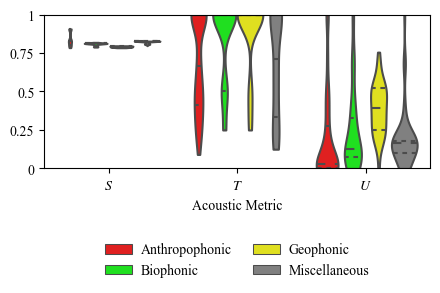

In [30]:
# (1) focus on (city, scene, sound) triples with at least one sound event
score = df_min_events.loc[min_event_mask, "soundmark_score"]

# number of triples with >= 1 event
n_entries = len(score)
feat_labels = ["S", "T", "U"]
n_feat = len(feat_labels)

# collect features in 2D feature matrix
feat_mat = np.zeros((n_entries, n_feat))
for f, feat_label in enumerate(feat_labels):
    feat_mat[:, f] = df_min_events.loc[min_event_mask, feat_label]

# 1) get index in class_labels of each sound class entry in sound_class_sected
sound_class_selected = df_min_events.loc[min_event_mask, "sound_class"]
sound_class_selected_idx = [class_labels.index(_) for _ in sound_class_selected]

# 2a) first index vector: corresponding sound category index
class_id_sound_cat = np.array([ss_class[_] for _ in sound_class_selected_idx])

cat_order = ['anthropophonic', 'biophonic', 'geophonic', 'miscellaneous']

# Map category -> color
palette = dict(zip(cat_order, SOUND_CAT_COLORS))

# focus on triples with at least one sound event
score = df_min_events.loc[min_event_mask, "soundmark_score"]

feat_labels = ["S", "T", "U"]
n_entries = len(score)

# Feature matrix
feat_mat = np.zeros((n_entries, len(feat_labels)))
for f, feat_label in enumerate(feat_labels):
    feat_mat[:, f] = df_min_events.loc[min_event_mask, feat_label].values

# Map sound class -> soundscape category
sound_class_selected = df_min_events.loc[min_event_mask, "sound_class"]
sound_class_selected_idx = [class_labels.index(_) for _ in sound_class_selected]
class_id_sound_cat = np.array([ss_class[_] for _ in sound_class_selected_idx])
category_names = [ss_class_mapping_back[i] for i in class_id_sound_cat]

# Create violin dataframe
df_violin = pd.DataFrame(feat_mat, columns=feat_labels)
df_violin["Category"] = pd.Categorical(
    category_names,
    categories=cat_order,
    ordered=True
)

# Long format
df_long = df_violin.melt(
    id_vars="Category",
    var_name="Acoustic Metric",
    value_name=""
)

# create figure
plt.figure(figsize=(4.5, 3))

sns.violinplot(
    data=df_long,
    x="Acoustic Metric",
    y="",
    hue="Category",
    hue_order=cat_order,
    palette=palette,     
    split=False,
    inner="quartile",
    cut=0
)

plt.ylim((0, 1))

# Legend below, full width, 2 columns
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(
    handles, [_.capitalize() for _ in labels],
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.4),   # push below axes
    ncol=2,
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.6,
)

plt.yticks([0, 0.25, 0.5, 0.75, 1],["0", "0.25", "0.5", "0.75", "1"])
plt.xticks([0, 1, 2],["$S$", "$T$", "$U$"])
plt.subplots_adjust(bottom=0.4)

plt.tight_layout()
plt.savefig(os.path.join('data', 'Figure_4.png'), dpi=300)
plt.show()

## Statistical test

Run Kruskal–Wallis tests for differences between categories and
provide epsilon-squared as a measure of the omnibus effect
size.

In [31]:
features = ["S", "T", "U"]
cat_order = ['anthropophonic', 'biophonic', 'geophonic', 'miscellaneous']

print(df_violin.shape)

all_H = np.zeros(3)

for f, feat in enumerate(features):
    
    print(f"\n=== Feature: {feat} ===")
    
    groups = [
        df_violin[df_violin["Category"] == cat][feat]
        for cat in cat_order
    ]

    # sample size (per category)
    n = [len(_) for _ in groups]

    # Kruskal-Wallis
    H, p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={H:.3f}, p={p:.5f}")
    
    if p < 0.05:
        print("Post-hoc Dunn test:")
        dunn = sp.posthoc_dunn(
            df_violin,
            val_col=feat,
            group_col="Category",
            p_adjust="holm"
        )
        print(dunn)
    all_H[f] = H

# compute effect sizes
n = df_violin.shape[0]
for i in range(3):
    eps_2 = (all_H[i] - 4 + 1) / (n - 4)
    print(features[i], ": eps_2 = ", str(eps_2))
    
    

(588, 4)

=== Feature: S ===
Kruskal-Wallis: H=217.766, p=0.00000
Post-hoc Dunn test:
                anthropophonic     biophonic     geophonic  miscellaneous
anthropophonic    1.000000e+00  6.450486e-14  9.264978e-43   5.237598e-02
biophonic         6.450486e-14  1.000000e+00  1.482716e-08   1.889634e-05
geophonic         9.264978e-43  1.482716e-08  1.000000e+00   5.274665e-22
miscellaneous     5.237598e-02  1.889634e-05  5.274665e-22   1.000000e+00

=== Feature: T ===
Kruskal-Wallis: H=46.324, p=0.00000
Post-hoc Dunn test:
                anthropophonic  biophonic     geophonic  miscellaneous
anthropophonic    1.000000e+00   0.000008  7.650468e-07       0.838296
biophonic         7.623775e-06   1.000000  8.299677e-01       0.000236
geophonic         7.650468e-07   0.829968  1.000000e+00       0.000031
miscellaneous     8.382964e-01   0.000236  3.079302e-05       1.000000

=== Feature: U ===
Kruskal-Wallis: H=84.497, p=0.00000
Post-hoc Dunn test:
                anthropophonic  bioph

# Lineare Regression Experiment with Leave-Two-Out Cross-Validation
- Leave-2-cities-out CV
- Feature importance investigation for Random Forest Models (this takes a bit of time)

In [32]:
# Prepare data
print(columns_features)
X = df[columns_features].to_numpy()
y = df["soundmark_score"].to_numpy()

X_cur = X[min_event_mask, :]
y_cur = y[min_event_mask]
city_ids_cur = city_ids[min_event_mask]

print("Feature matrix shape:", X_cur.shape)
print("Features:", columns_features)

# set-up cross validation
lpgo = LeavePGroupsOut(n_groups=2)

r2_scores = []
mae_scores = []
corr_scores = []

# define models
models = []
model_labels = []

models.append(Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0, random_state=0))
]))
model_labels.append("ridge_lin")

models.append(Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=10.0, random_state=0))
]))
model_labels.append("ridge_pol")

models.append(Pipeline([("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                        ("rf", RandomForestRegressor(n_estimators=100,
                                                     max_features="sqrt",
                                                     min_samples_leaf=5,
                                                     n_jobs=-1,
                                                     random_state=0))]))
model_labels.append("rf")

models.append(Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("hgb", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=500,
        random_state=0
    ))
]))
model_labels.append("hgb")

models.append(Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf", alpha=1.0, gamma=0.1))
]))

model_labels.append("krr")

n_configs = len(models)

# CV

all_importances = []

for f, (train_idx, test_idx) in tqdm(enumerate(lpgo.split(X_cur, y_cur, groups=city_ids_cur))):
    
    cur_r2_scores = []
    cur_corr = []
    cur_mae_scores = []
    best_params_per_fold = []
    
    # define training and test set
    X_train, X_test = X_cur[train_idx], X_cur[test_idx]
    y_train, y_test = y_cur[train_idx], y_cur[test_idx]
    groups_train = city_ids_cur[train_idx]
    
    for i in range(n_configs):
        
        models[i].fit(X_train, y_train)

        if model_labels[i] == 'rf':
            
            result = permutation_importance(models[i],
                                            X_test,
                                            y_test,
                                            scoring="r2",
                                            n_repeats=50,
                                            random_state=0,
                                            n_jobs=-1)

            fold_df = pd.DataFrame({
                "fold": f,
                "feature": columns_features,
                "importance": result.importances_mean
            })
            all_importances.append(fold_df)

        # Test R²
        y_pred = models[i].predict(X_test)
        cur_r2_scores.append(r2_score(y_test, y_pred))
        cur_mae_scores.append(mean_absolute_error(y_test, y_pred))
        cur_corr.append(np.corrcoef(y_test, y_pred)[0, 1])

    r2_scores.append(cur_r2_scores)
    mae_scores.append(cur_mae_scores)
    corr_scores.append(cur_corr)
    
all_importances = pd.concat(all_importances, ignore_index=True)

summary = (
    all_importances
    .groupby("feature")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

print(summary)
    
r2_scores = np.array(r2_scores)
r2_m = r2_scores.mean(axis=0)
r2_v = r2_scores.std(axis=0)

mae_scores = np.array(mae_scores)
mae_m = mae_scores.mean(axis=0)
mae_v = mae_scores.std(axis=0)

corr_scores = np.array(corr_scores)
c_m = corr_scores.mean(axis=0)
c_v = corr_scores.std(axis=0)


for i in range(n_configs):
    print(f"{model_labels[i]} & {r2_m[i]:.2f} ({r2_v[i]:.2f}) & {mae_m[i]:.2f} ({mae_v[i]:.2f}) & {c_m[i]:.2f} ({c_v[i]:.2f}) \\\\")


['S', 'T', 'U']
Feature matrix shape: (588, 3)
Features: ['S', 'T', 'U']


45it [06:00,  8.00s/it]

             mean       std
feature                    
S        0.353887  0.050154
U        0.054822  0.037357
T        0.004123  0.017955
ridge_lin & 0.06 (0.03) & 0.20 (0.01) & 0.25 (0.05) \\
ridge_pol & 0.05 (0.02) & 0.20 (0.01) & 0.24 (0.04) \\
rf & 0.24 (0.07) & 0.17 (0.01) & 0.50 (0.07) \\
hgb & 0.19 (0.13) & 0.17 (0.01) & 0.50 (0.08) \\
krr & 0.10 (0.04) & 0.19 (0.01) & 0.33 (0.06) \\
